# Capítulo 10 · Entrenamiento y validación

En el capítulo anterior construimos una red completa para clasificar dos medias lunas. Registramos `loss`, `accuracy`, `val_loss` y `val_accuracy`, pero los usamos principalmente para comprobar que el entrenamiento estaba funcionando.

En este cuaderno retomaremos el mismo problema y aprenderemos a leer el entrenamiento como un proceso. Las métricas finales serán una fotografía; las curvas a lo largo de las epochs nos mostrarán la película completa.

## Objetivos del capítulo

Al finalizar este recorrido podrás:

- diferenciar el papel de entrenamiento, validación y prueba;
- recuperar y organizar la información guardada por `fit()`;
- graficar pérdida y *accuracy* a lo largo de las epochs;
- interpretar tendencias, brechas, fluctuaciones y estabilización;
- explicar por qué pérdida y *accuracy* no cuentan exactamente la misma historia;
- reconocer señales de aprendizaje razonable, posible sobreajuste o falta de aprendizaje;
- localizar la epoch con menor pérdida de validación;
- utilizar `EarlyStopping` para detener el entrenamiento y restaurar los mejores pesos;
- reservar el conjunto de prueba para una evaluación final independiente.

## Importación de librerías

Usaremos el mismo dataset sintético y la misma arquitectura del capítulo 9. NumPy y Pandas organizarán los resultados, Matplotlib mostrará las curvas, Scikit-learn preparará las particiones y TensorFlow/Keras realizará los entrenamientos.

In [1]:
import os

# Reduce mensajes técnicos que no forman parte de la práctica.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

SEMILLA_DATOS = 42
SEMILLA_MODELO = 42

print(f"TensorFlow: {tf.__version__}")
print("GPU disponible:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU disponible: False


## 1. Tres conjuntos con funciones diferentes

Generaremos nuevamente 1000 observaciones con forma de medias lunas. Primero reservaremos el 20 % como prueba. Después separaremos otro 20 % del conjunto restante para validación.

La red aprenderá solamente con `X_train` e `y_train`. Usaremos validación para observar y tomar decisiones, mientras que prueba permanecerá apartada hasta el final.

In [2]:
X, y = make_moons(
    n_samples=1000,
    noise=0.15,
    random_state=SEMILLA_DATOS,
)

X = X.astype("float32")
y = y.astype("float32")

X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA_DATOS,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_desarrollo,
    y_desarrollo,
    test_size=0.20,
    random_state=SEMILLA_DATOS,
    stratify=y_desarrollo,
)

particiones = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "Observaciones": [len(X_train), len(X_val), len(X_test)],
    "Actualiza pesos": ["Sí", "No", "No"],
    "Uso principal": [
        "Aprender parámetros",
        "Observar y orientar decisiones",
        "Evaluar al final",
    ],
})

display(particiones)

,Conjunto,Observaciones,Actualiza pesos,Uso principal
0,Entrenamiento,640,Sí,Aprender parámetros
1,Validación,160,No,Observar y orientar decisiones
2,Prueba,200,No,Evaluar al final


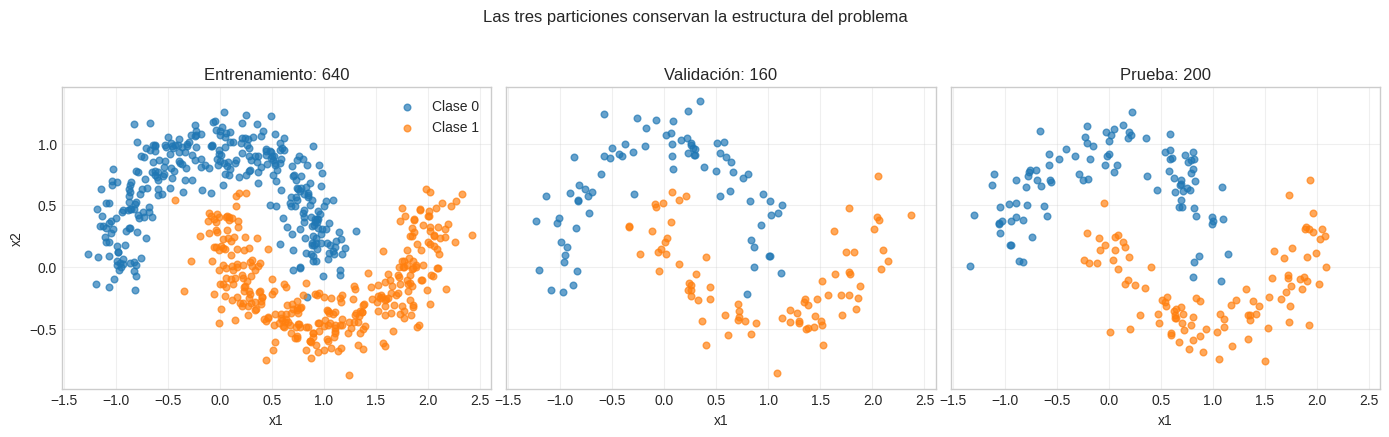

In [3]:
conjuntos = [
    (X_train, y_train, "Entrenamiento"),
    (X_val, y_val, "Validación"),
    (X_test, y_test, "Prueba"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True, sharey=True)

for ax, (X_parte, y_parte, nombre) in zip(axes, conjuntos):
    ax.scatter(
        X_parte[y_parte == 0, 0],
        X_parte[y_parte == 0, 1],
        s=23,
        alpha=0.68,
        label="Clase 0",
    )
    ax.scatter(
        X_parte[y_parte == 1, 0],
        X_parte[y_parte == 1, 1],
        s=23,
        alpha=0.68,
        label="Clase 1",
    )
    ax.set_title(f"{nombre}: {len(X_parte)}")
    ax.set_xlabel("x1")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("x2")
axes[0].legend()
fig.suptitle("Las tres particiones conservan la estructura del problema", y=1.03)
plt.tight_layout()
plt.show()

Las tres particiones contienen ambas clases y mantienen la geometría general del problema. Validación y prueba no actualizan los pesos, pero tampoco son intercambiables: la validación orientará el desarrollo y la prueba proporcionará una evaluación final.

La separación explícita permite ver sus tamaños y evita consultar accidentalmente el conjunto de prueba durante el entrenamiento.

## 2. Retomar la red del capítulo anterior

Usaremos nuevamente la arquitectura:

$$
2\rightarrow8\rightarrow4\rightarrow1
$$

Las capas ocultas emplean ReLU y la salida utiliza sigmoid. Binary Cross-Entropy será la pérdida y Adam el optimizador.

La función `crear_modelo()` nos permitirá construir dos copias independientes de la misma arquitectura: una para estudiar las curvas y otra para observar `EarlyStopping`.

In [4]:
def crear_modelo(learning_rate=0.001, semilla=SEMILLA_MODELO):
    keras.backend.clear_session()
    keras.utils.set_random_seed(semilla)

    modelo = keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return modelo


modelo_base = crear_modelo()
modelo_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

La red conserva los 65 parámetros del capítulo 9. Aquí no volveremos a analizar su conteo ni la frontera de decisión: el foco estará en cómo evolucionan la pérdida y la *accuracy* sobre entrenamiento y validación.

## 3. El entrenamiento deja una historia

Entrenaremos durante 100 epochs. En lugar de usar `validation_split`, pasaremos explícitamente `(X_val, y_val)` mediante `validation_data` para que el papel de cada partición sea visible.

`fit()` devolverá un objeto `History` con un valor por epoch para cada cantidad registrada.

In [5]:
historial_base = modelo_base.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=True,
    verbose=0,
)

print("Claves registradas:", list(historial_base.history.keys()))
print("Cantidad de epochs registradas:", len(historial_base.history["loss"]))

Claves registradas: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
Cantidad de epochs registradas: 100


Las cuatro claves describen dos cantidades —pérdida y *accuracy*— sobre dos conjuntos —entrenamiento y validación—. Como se ejecutaron 100 epochs, cada secuencia contiene 100 valores.

La validación realizó *forward pass* y calculó métricas al final de cada epoch, pero no produjo backpropagation ni actualizaciones de parámetros.

In [6]:
tabla_historial = pd.DataFrame(historial_base.history)
tabla_historial.index = np.arange(1, len(tabla_historial) + 1)
tabla_historial.index.name = "Epoch"

epochs_seleccionadas = [1, 2, 5, 10, 20, 40, 60, 80, 100]
display(tabla_historial.loc[epochs_seleccionadas])

,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
1,0.4922,0.6641,0.5000,0.6514
2,0.4984,0.6439,0.5000,0.6322
5,0.6984,0.5939,0.7250,0.5823
10,0.7328,0.5114,0.7500,0.5002
20,0.7812,0.3964,0.8000,0.4107
40,0.8672,0.2823,0.8375,0.3264
60,0.8734,0.2457,0.8438,0.2936
80,0.8766,0.2257,0.8625,0.2725
100,0.8953,0.2025,0.8750,0.2481


La tabla permite comparar momentos concretos. Durante las primeras epochs los cambios suelen ser mayores; más adelante pueden volverse pequeños a medida que el proceso se estabiliza.

No necesitamos que los valores de entrenamiento y validación sean idénticos. Nos interesa si mejoran de manera coherente y en qué nivel se encuentran.

## 4. Graficar pérdida y accuracy

Las tablas son útiles para consultar valores exactos, pero las curvas permiten reconocer tendencias. Graficaremos las cuatro secuencias usando el mismo eje de epochs.

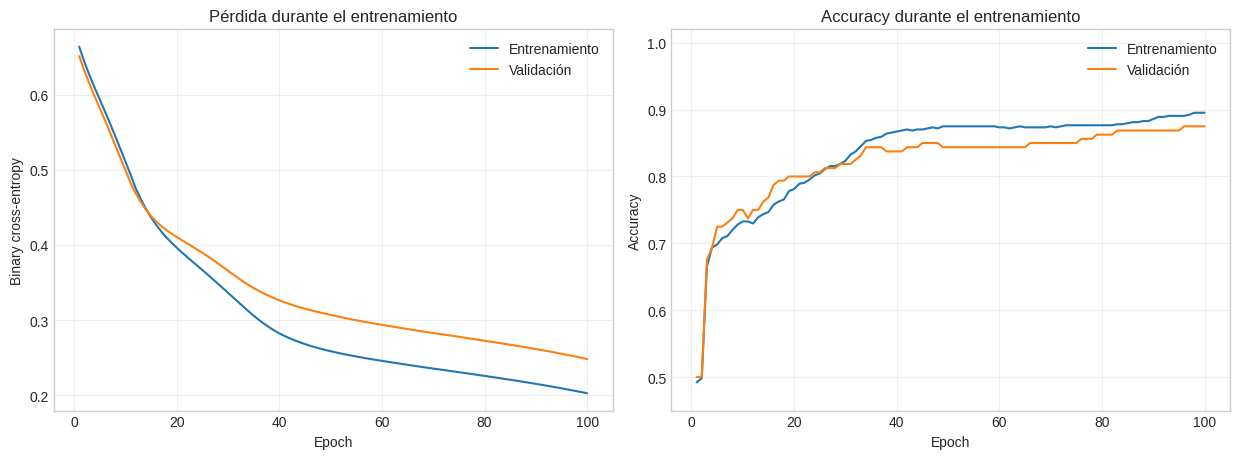

In [7]:
eje_epochs = tabla_historial.index.to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))

axes[0].plot(eje_epochs, tabla_historial["loss"], label="Entrenamiento")
axes[0].plot(eje_epochs, tabla_historial["val_loss"], label="Validación")
axes[0].set_title("Pérdida durante el entrenamiento")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(eje_epochs, tabla_historial["accuracy"], label="Entrenamiento")
axes[1].plot(eje_epochs, tabla_historial["val_accuracy"], label="Validación")
axes[1].set_title("Accuracy durante el entrenamiento")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.45, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Las curvas muestran una mejora sostenida sobre ambos conjuntos. Las pequeñas diferencias y oscilaciones no constituyen por sí solas un problema: trabajamos con mini-batches y con una muestra de validación limitada.

La relación entre las curvas importa tanto como su dirección. Si entrenamiento siguiera mejorando mientras validación empeorara de forma sostenida, tendríamos una señal de posible sobreajuste. Su estudio detallado corresponde al capítulo 11.

### ¿Y si validación parece mejor que entrenamiento?

En algunas ejecuciones puede ocurrir que `val_loss` sea menor que `loss` o que `val_accuracy` resulte mayor que `accuracy`. Esto no implica automáticamente un error: la porción de validación puede ser algo más sencilla que la de entrenamiento. Más adelante también conoceremos técnicas que agregan dificultad solamente durante el aprendizaje.

Las curvas son señales estadísticas. No existe una regla que obligue a validación a ser siempre peor, ni una distancia universal que separe un comportamiento aceptable de uno problemático.

## 5. Medir lo que vemos

La lectura visual puede complementarse con algunas cifras sencillas. Buscaremos la epoch con menor `val_loss`, calcularemos la brecha final entre las *accuracies* y mediremos cuánto cambió la pérdida de validación durante las últimas diez epochs.

Estas cantidades ayudan a describir el recorrido, pero no forman una regla automática para decidir si un modelo es bueno.

In [8]:
mejor_epoch = int(tabla_historial["val_loss"].idxmin())
ultima_epoch = int(tabla_historial.index[-1])

resumen_curvas = pd.DataFrame({
    "Cantidad": [
        "Epoch con menor val_loss",
        "Menor val_loss",
        "Val_accuracy en esa epoch",
        "Brecha final de accuracy (train - val)",
        "Cambio de val_loss en las últimas 10 epochs",
    ],
    "Valor": [
        mejor_epoch,
        tabla_historial.loc[mejor_epoch, "val_loss"],
        tabla_historial.loc[mejor_epoch, "val_accuracy"],
        tabla_historial.loc[ultima_epoch, "accuracy"]
        - tabla_historial.loc[ultima_epoch, "val_accuracy"],
        tabla_historial.loc[ultima_epoch, "val_loss"]
        - tabla_historial.loc[ultima_epoch - 10, "val_loss"],
    ],
})

display(resumen_curvas)

,Cantidad,Valor
0,Epoch con menor val_loss,100.0000
1,Menor val_loss,0.2481
2,Val_accuracy en esa epoch,0.8750
3,Brecha final de accuracy (train - val),0.0203
4,Cambio de val_loss en las últimas 10 epochs,-0.0133


La mejor epoch según `val_loss` es una observación sobre esta ejecución y esta partición, no una constante del problema. Una brecha pequeña puede ser favorable, pero también debemos mirar el nivel alcanzado: dos *accuracies* cercanas a 0.50 serían parecidas y, al mismo tiempo, poco útiles en un problema binario equilibrado.

El cambio reciente de `val_loss` permite advertir si las mejoras se están volviendo pequeñas. Esto se relaciona con la idea de convergencia estudiada al analizar descenso por gradiente.

## 6. Accuracy y pérdida cuentan historias distintas

La *accuracy* solo cambia cuando una probabilidad cruza el umbral de decisión. La pérdida, en cambio, registra desplazamientos continuos en las probabilidades.

Buscaremos dos epochs consecutivas con la misma `val_accuracy` pero con menor `val_loss` en la segunda. Si existen, veremos un caso real en el que las clases acertadas no cambian aunque las probabilidades sí mejoren.

In [9]:
par_encontrado = None

for epoch in range(2, len(tabla_historial) + 1):
    anterior = tabla_historial.loc[epoch - 1]
    actual = tabla_historial.loc[epoch]

    misma_accuracy = np.isclose(
        anterior["val_accuracy"],
        actual["val_accuracy"],
    )
    menor_perdida = actual["val_loss"] < anterior["val_loss"]

    if misma_accuracy and menor_perdida:
        par_encontrado = [epoch - 1, epoch]
        break

if par_encontrado is not None:
    display(
        tabla_historial.loc[
            par_encontrado,
            ["val_loss", "val_accuracy"],
        ]
    )
else:
    print("En esta ejecución no apareció un par consecutivo con ese patrón.")

,val_loss,val_accuracy
Epoch,,
1,0.6514,0.5000
2,0.6322,0.5000


En el par encontrado, `val_accuracy` permanece igual porque se acierta la misma cantidad de etiquetas. Sin embargo, `val_loss` disminuye: las probabilidades se desplazaron en una dirección más favorable sin modificar todavía las decisiones producidas por el umbral.

Por eso conviene leer ambas curvas. La *accuracy* es intuitiva, mientras que la pérdida conserva información más fina sobre las salidas del modelo.

## 7. Tres patrones de referencia

Antes de utilizar una herramienta automática, comparemos tres formas frecuentes de curvas. El siguiente gráfico es **esquemático**: no proviene de nuevos entrenamientos y sus valores solo sirven para practicar la lectura de tendencias.

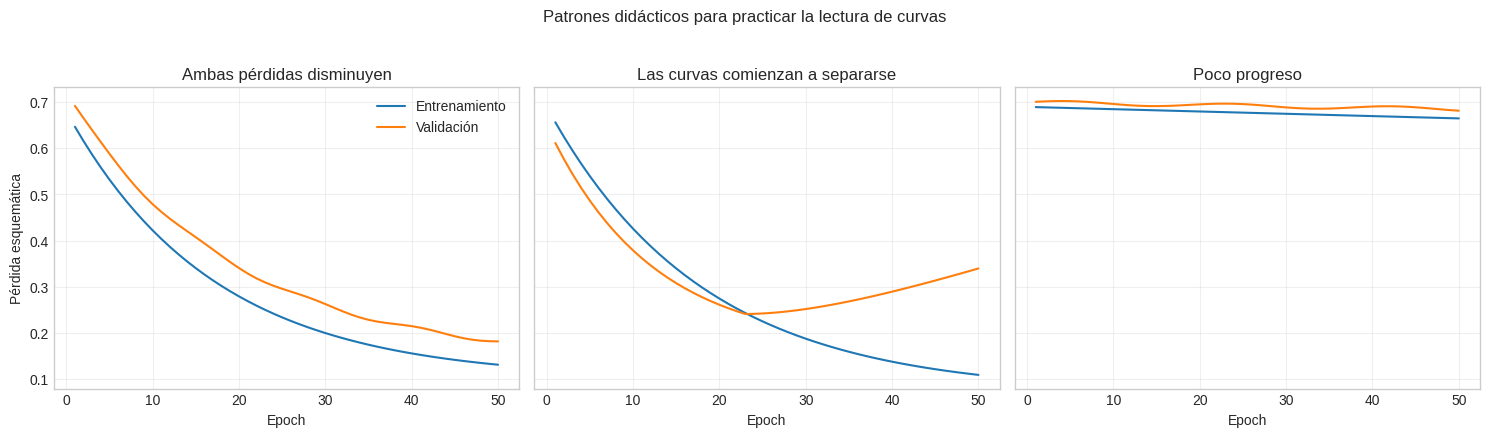

In [10]:
epochs_esquema = np.arange(1, 51)

train_favorable = 0.58 * np.exp(-epochs_esquema / 17) + 0.10
val_favorable = (
    0.58 * np.exp(-epochs_esquema / 19)
    + 0.14
    + 0.004 * np.sin(epochs_esquema / 2)
)

train_separacion = 0.62 * np.exp(-epochs_esquema / 18) + 0.07
val_separacion = (
    0.48 * np.exp(-epochs_esquema / 12)
    + 0.17
    + 0.006 * np.maximum(epochs_esquema - 23, 0)
)

train_estancada = 0.69 - 0.0005 * epochs_esquema
val_estancada = 0.70 - 0.0003 * epochs_esquema + 0.004 * np.sin(epochs_esquema / 3)

escenarios = [
    (train_favorable, val_favorable, "Ambas pérdidas disminuyen"),
    (train_separacion, val_separacion, "Las curvas comienzan a separarse"),
    (train_estancada, val_estancada, "Poco progreso"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, (curva_train, curva_val, titulo) in zip(axes, escenarios):
    ax.plot(epochs_esquema, curva_train, label="Entrenamiento")
    ax.plot(epochs_esquema, curva_val, label="Validación")
    ax.set_title(titulo)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Pérdida esquemática")
axes[0].legend()
fig.suptitle("Patrones didácticos para practicar la lectura de curvas", y=1.03)
plt.tight_layout()
plt.show()

El primer patrón sugiere aprendizaje coherente. El segundo presenta una señal de posible sobreajuste: entrenamiento mejora mientras validación cambia de tendencia. El tercero sugiere que el modelo no está aprendiendo lo suficiente.

Estas formas no son diagnósticos automáticos. Deben interpretarse junto con el nivel de las métricas, el tamaño y ruido del dataset, la arquitectura y la configuración del entrenamiento. Una oscilación aislada tampoco define una tendencia.

## 8. El mejor modelo puede no estar en la última epoch

Si `val_loss` alcanza un mínimo y luego deja de mejorar, los pesos de la última epoch no son necesariamente los más convenientes. Keras ofrece el callback `EarlyStopping` para observar una métrica y detener el proceso después de varias epochs sin mejora.

Utilizaremos:

- `monitor="val_loss"` para vigilar la pérdida de validación;
- `patience=5` para tolerar cinco epochs sin mejora;
- `restore_best_weights=True` para recuperar los pesos de la mejor epoch.

El máximo será 300 epochs, pero no esperamos que el entrenamiento necesite ejecutarlas todas.

In [11]:
PACIENCIA = 5
MAXIMO_EPOCHS = 300

# El learning rate de 0.005 permite observar la detención en un tiempo breve.
# No se propone como un valor universalmente mejor.
modelo_early = crear_modelo(learning_rate=0.005)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PACIENCIA,
    restore_best_weights=True,
)

historial_early = modelo_early.fit(
    X_train,
    y_train,
    epochs=MAXIMO_EPOCHS,
    batch_size=32,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stopping],
    verbose=0,
)

tabla_early = pd.DataFrame(historial_early.history)
tabla_early.index = np.arange(1, len(tabla_early) + 1)
tabla_early.index.name = "Epoch"

mejor_epoch_early = int(tabla_early["val_loss"].idxmin())

print("Máximo permitido:", MAXIMO_EPOCHS)
print("Epochs ejecutadas:", len(tabla_early))
print("Mejor epoch según val_loss:", mejor_epoch_early)
print("Menor val_loss registrada:", f"{tabla_early['val_loss'].min():.4f}")

Máximo permitido: 300
Epochs ejecutadas: 160
Mejor epoch según val_loss: 155
Menor val_loss registrada: 0.0238


El entrenamiento se detuvo antes del máximo porque `val_loss` dejó de establecer nuevos mínimos durante cinco epochs consecutivas. `patience` evita reaccionar ante una única fluctuación.

La última fila del historial corresponde a la última epoch ejecutada, pero `restore_best_weights=True` hace que el modelo conserve finalmente los parámetros de la mejor epoch observada.

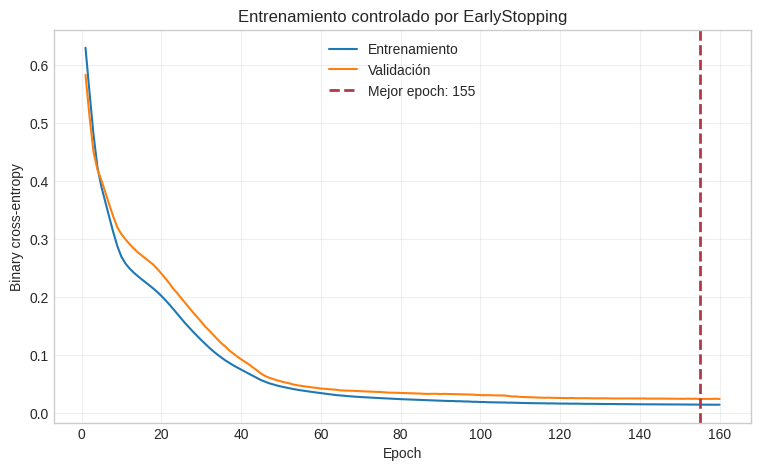

In [12]:
eje_early = tabla_early.index.to_numpy()

fig, ax = plt.subplots(figsize=(9, 5.1))
ax.plot(eje_early, tabla_early["loss"], label="Entrenamiento")
ax.plot(eje_early, tabla_early["val_loss"], label="Validación")
ax.axvline(
    mejor_epoch_early,
    color="#b23a48",
    linestyle="--",
    linewidth=2,
    label=f"Mejor epoch: {mejor_epoch_early}",
)
ax.set_title("Entrenamiento controlado por EarlyStopping")
ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

La línea vertical identifica el menor `val_loss`. El entrenamiento continúa unas pocas epochs después de ese punto porque la paciencia permite comprobar si la mejora reaparece.

`EarlyStopping` no demuestra por sí solo que la red generalice bien. Utiliza validación para tomar una decisión de desarrollo; por eso todavía necesitamos evaluar una vez sobre prueba.

## 9. Evaluación final sobre prueba

Hasta aquí el conjunto de prueba no participó de las decisiones. Ahora evaluaremos el modelo cuyos mejores pesos de validación fueron restaurados y compararemos el resultado con la evaluación sobre validación.

In [13]:
perdida_val, accuracy_val = modelo_early.evaluate(
    X_val,
    y_val,
    verbose=0,
)
perdida_test, accuracy_test = modelo_early.evaluate(
    X_test,
    y_test,
    verbose=0,
)

evaluacion_final = pd.DataFrame({
    "Conjunto": ["Validación", "Prueba"],
    "Loss": [perdida_val, perdida_test],
    "Accuracy": [accuracy_val, accuracy_test],
})

display(evaluacion_final)

,Conjunto,Loss,Accuracy
0,Validación,0.0238,0.9875
1,Prueba,0.0090,0.9950


La evaluación de prueba proporciona una estimación más independiente porque no se utilizó para elegir la epoch ni para activar la detención. El resultado es muy alto en este dataset sintético pequeño, pero no implica que el modelo sea perfecto en cualquier contexto ni que la misma configuración funcione igual con otros datos.

Si consultáramos prueba después de cada cambio y ajustáramos el modelo según su resultado, ese conjunto también comenzaría a influir en el desarrollo y perdería parte de su independencia.

## 10. Una mirada alrededor de la mejor epoch

La siguiente celda muestra algunas epochs antes y después del mínimo de validación. Podés modificar `ventana` para ampliar o reducir el intervalo.

In [14]:
ventana = 5
inicio = max(1, mejor_epoch_early - ventana)
fin = min(len(tabla_early), mejor_epoch_early + ventana)

display(
    tabla_early.loc[
        inicio:fin,
        ["loss", "val_loss", "accuracy", "val_accuracy"],
    ]
)

,loss,val_loss,accuracy,val_accuracy
Epoch,,,,
150,0.0144,0.0242,0.9953,0.9875
151,0.0143,0.0242,0.9969,0.9875
152,0.0142,0.0244,0.9969,0.9875
153,0.0143,0.0241,0.9953,0.9875
154,0.0141,0.0244,0.9969,0.9875
155,0.0143,0.0238,0.9953,0.9875
156,0.0141,0.0240,0.9969,0.9875
157,0.0141,0.0240,0.9969,0.9875
158,0.0141,0.0240,0.9969,0.9875


Los valores cercanos permiten comprobar que una pequeña subida aislada no detiene inmediatamente el proceso. Solo después de acumular la cantidad de epochs definida por `patience` sin un nuevo mínimo finaliza el entrenamiento.

Como actividad, modificá `PACIENCIA` en la sección anterior y ejecutá nuevamente desde la creación de `modelo_early`. Compará la cantidad de epochs ejecutadas y la mejor epoch sin asumir que una paciencia menor o mayor será siempre preferible.

## 11. Qué agregamos al flujo de trabajo

En el capítulo 9 resumíamos el proceso como:

**construir → compilar → entrenar → evaluar**

Ahora podemos precisarlo:

**construir → compilar → entrenar observando validación → analizar curvas → decidir cuándo detener → evaluar sobre prueba**

Entrenamiento ajusta los parámetros. Validación orienta decisiones durante el desarrollo. Prueba se reserva para estimar el rendimiento final. Las curvas convierten el aprendizaje en un proceso observable en lugar de una operación que simplemente esperamos que termine.

## Cierre

En este capítulo retomamos la red del problema de las dos lunas y estudiamos la historia almacenada por `fit()`. Organizamos `loss`, `accuracy`, `val_loss` y `val_accuracy`, las representamos mediante curvas y complementamos la lectura visual con medidas sencillas.

Comprobamos que pérdida y *accuracy* pueden evolucionar de forma diferente, que las fluctuaciones aisladas son normales y que la relación entre entrenamiento y validación aporta información sobre generalización, estabilización y posibles problemas.

Finalmente utilizamos `EarlyStopping` para detener el proceso después de varias epochs sin mejora y restaurar los pesos correspondientes al mejor `val_loss`. El conjunto de prueba permaneció apartado hasta la evaluación final.

En el próximo capítulo estudiaremos con más detalle el sobreajuste y las estrategias para reducirlo, entre ellas el control de la capacidad, la regularización y dropout.

## Para pensar

1. ¿Por qué `val_loss` puede influir en nuestras decisiones aunque no participe de backpropagation?
2. ¿Cómo puede disminuir la pérdida mientras la *accuracy* permanece igual?
3. ¿Por qué una subida aislada de `val_loss` no alcanza para diagnosticar sobreajuste?
4. ¿Qué diferencia existe entre la última epoch ejecutada y la mejor epoch restaurada por `EarlyStopping`?
5. ¿Qué perderíamos si consultáramos el conjunto de prueba después de cada cambio del modelo?

---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
